# Understanding Backpropagation with Computational Graphs

> **Goal**: Build an intuition for *how* gradients flow backward through a neural network by
> visualising the computational graph at every single step.

---

## What You Will Learn
| Topic | What we cover |
|---|---|
| Forward pass | Build the expression graph and compute values |
| Chain Rule | Derive every local gradient by hand |
| Graph visualisation | See the graph *change* as gradients are filled in |
| Automated backward | Let `Value._backward()` do the work |
| Multi-use variables | The `+=` accumulation fix |
| A real neuron | One neuron, full backprop, visualised |


## 0. Setup
Imports + Graphviz path fix (Windows).

In [1]:
import math
import os
os.environ['PATH'] += os.pathsep + 'C:/Program Files/Graphviz/bin'
from graphviz import Digraph
print('Ready!')

Ready!


## 1. The `Value` Engine

We wrap every scalar number in a `Value` object that automatically builds a
**directed acyclic graph (DAG)** of operations as you compute.

Every `Value` stores:
| Attribute | Meaning |
|---|---|
| `data` | The actual number (forward pass result) |
| `grad` | Gradient of the final output w.r.t. this value |
| `_prev` | Parent nodes that created this value |
| `_op` | Which operation created it (`+`, `*`, `tanh`, …) |
| `_backward` | Closure that propagates `grad` to its parents |


In [2]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(label={self.label!r}, data={self.data:.4f}, grad={self.grad:.4f})'

    # ── arithmetic ────────────────────────────────────────────────
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            # d(out)/d(self) = 1   →  chain rule: self.grad += 1 * out.grad
            self.grad  += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other): return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            # d(self*other)/d(self) = other.data
            self.grad  += other.data * out.grad
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other): return self * other
    def __neg__(self): return self * -1
    def __sub__(self, other): return self + (-other)
    def __rsub__(self, other): return Value(other) + (-self)
    def __truediv__(self, other): return self * other**-1

    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += other * (self.data**(other - 1)) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), 'tanh')
        def _backward():
            # d(tanh(x))/dx = 1 - tanh(x)^2
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        t = math.exp(self.data)
        out = Value(t, (self,), 'exp')
        def _backward():
            self.grad += t * out.grad   # d(e^x)/dx = e^x
        out._backward = _backward
        return out

    def relu(self):
        t = max(0, self.data)
        out = Value(t, (self,), 'relu')
        def _backward():
            self.grad += (1.0 if self.data > 0 else 0.0) * out.grad
        out._backward = _backward
        return out

    # ── full automated backward ───────────────────────────────────
    def backward(self):
        """Topological sort then call _backward() from output → inputs."""
        topo, visited = [], set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)
        build(self)
        self.grad = 1.0          # dL/dL = 1  (seed gradient)
        for node in reversed(topo):
            node._backward()

print('Value class defined.')

Value class defined.


## 2. Graph Visualiser

`draw_dot(root)` renders the full computational graph.  
Each node shows: **label | data | grad**

In [3]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, title=''):
    dot = Digraph(
        comment=title,
        format='svg',
        graph_attr={'rankdir': 'LR', 'label': title, 'fontsize': '16'}
    )
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(
            name=uid,
            label='{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad),
            shape='record'
        )
        if n._op:
            dot.node(name=uid + n._op, label=n._op, shape='circle')
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

print('draw_dot() defined.')

draw_dot() defined.


---
## 3. A Simple Expression: `L = (a * b + c) * f`

We will trace through backpropagation **one step at a time** and redraw
the graph each time so you can see exactly which gradient changed.

### 3.1 Forward Pass – Build the graph, compute values

```
a=2, b=-3, c=10, f=-2
e = a * b = -6
d = e + c = 4
L = d * f = -8   ← our 'loss'
```


Forward pass complete:
  e = a*b = -6.0
  d = e+c = 4.0
  L = d*f = -8.0


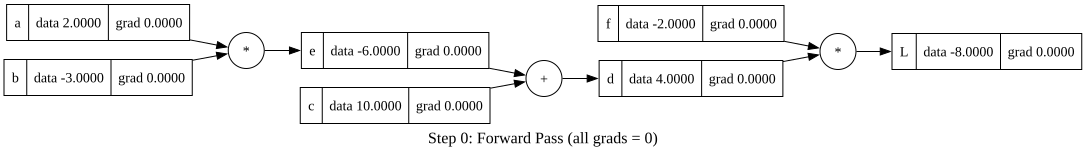

In [4]:
# ── Forward pass ──────────────────────────────────────────────────
a = Value( 2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
f = Value(-2.0, label='f')

e = a * b;  e.label = 'e'
d = e + c;  d.label = 'd'
L = d * f;  L.label = 'L'

print('Forward pass complete:')
print(f'  e = a*b = {e.data}')
print(f'  d = e+c = {d.data}')
print(f'  L = d*f = {L.data}')

draw_dot(L, title='Step 0: Forward Pass (all grads = 0)')

### 3.2 Step 1 — Seed the output gradient

We want $\dfrac{\partial L}{\partial L} = 1$. This is always the starting point.


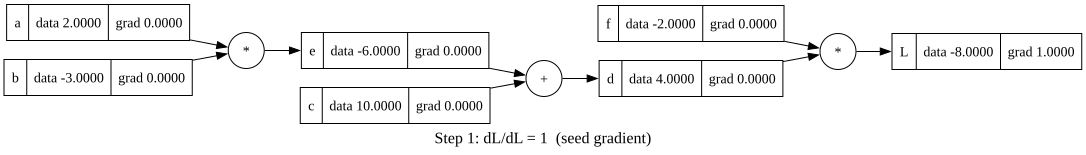

In [5]:
L.grad = 1.0
draw_dot(L, title='Step 1: dL/dL = 1  (seed gradient)')

### 3.3 Step 2 — Backprop through `L = d * f`

For multiplication $L = d \times f$:
$$\frac{\partial L}{\partial d} = f = -2 \qquad \frac{\partial L}{\partial f} = d = 4$$
Chain rule: $d.\text{grad} = \frac{\partial L}{\partial d} \times L.\text{grad} = -2 \times 1 = -2$


d.grad = -2.0  (= f.data × L.grad = -2.0 × 1.0)
f.grad = 4.0  (= d.data × L.grad = 4.0 × 1.0)


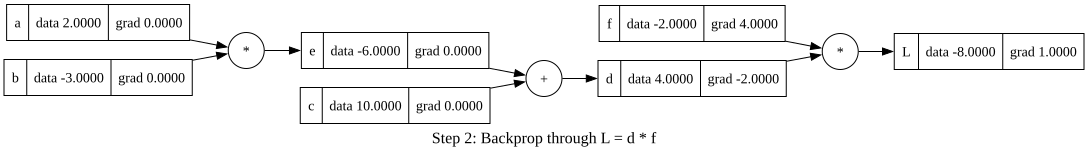

In [6]:
# Manually apply the chain rule for L = d * f
d.grad = f.data * L.grad   # = -2 * 1 = -2
f.grad = d.data * L.grad   # =  4 * 1 =  4

print(f'd.grad = {d.grad}  (= f.data × L.grad = {f.data} × {L.grad})')
print(f'f.grad = {f.grad}  (= d.data × L.grad = {d.data} × {L.grad})')

draw_dot(L, title='Step 2: Backprop through L = d * f')

### 3.4 Step 3 — Backprop through `d = e + c`

For addition $d = e + c$:
$$\frac{\partial d}{\partial e} = 1 \qquad \frac{\partial d}{\partial c} = 1$$
So the gradient **passes through unchanged**:
$e.\text{grad} = 1 \times d.\text{grad} = -2$, same for $c$.


e.grad = -2.0  (addition: gradient passes through with multiplier 1)
c.grad = -2.0


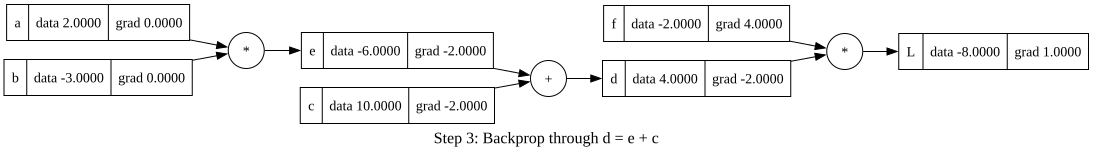

In [7]:
e.grad = 1.0 * d.grad   # = -2
c.grad = 1.0 * d.grad   # = -2

print(f'e.grad = {e.grad}  (addition: gradient passes through with multiplier 1)')
print(f'c.grad = {c.grad}')

draw_dot(L, title='Step 3: Backprop through d = e + c')

### 3.5 Step 4 — Backprop through `e = a * b`

For multiplication $e = a \times b$:
$$\frac{\partial e}{\partial a} = b = -3 \qquad \frac{\partial e}{\partial b} = a = 2$$
Chain rule:
$$a.\text{grad} = b \times e.\text{grad} = -3 \times -2 = 6$$
$$b.\text{grad} = a \times e.\text{grad} = 2 \times -2 = -4$$


a.grad = 6.0  (= b.data × e.grad = -3.0 × -2.0)
b.grad = -4.0  (= a.data × e.grad = 2.0 × -2.0)


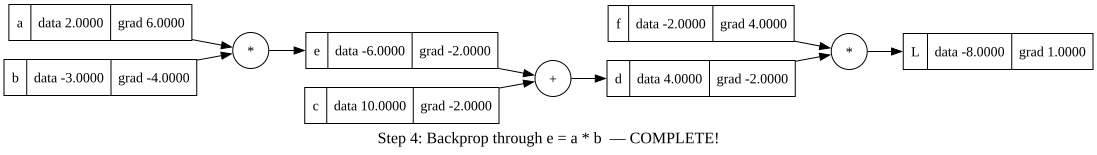

In [8]:
a.grad = b.data * e.grad   # = -3 * -2 = 6
b.grad = a.data * e.grad   # =  2 * -2 = -4

print(f'a.grad = {a.grad}  (= b.data × e.grad = {b.data} × {e.grad})')
print(f'b.grad = {b.grad}  (= a.data × e.grad = {a.data} × {e.grad})')

draw_dot(L, title='Step 4: Backprop through e = a * b  — COMPLETE!')

### 3.6 Verify with automated `.backward()`

Our manual calculation should match `backward()` exactly.


Automated backward results:
  Value(label='L', data=-8.0000, grad=1.0000)
  Value(label='d', data=4.0000, grad=-2.0000)
  Value(label='f', data=-2.0000, grad=4.0000)
  Value(label='e', data=-6.0000, grad=-2.0000)
  Value(label='c', data=10.0000, grad=-2.0000)
  Value(label='a', data=2.0000, grad=6.0000)
  Value(label='b', data=-3.0000, grad=-4.0000)


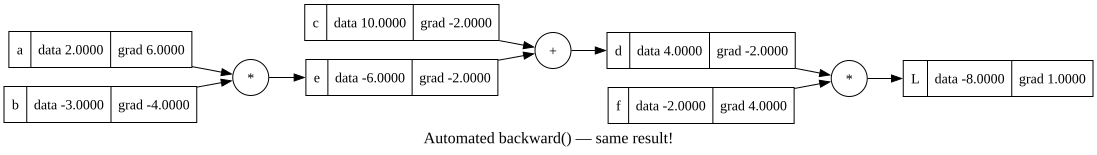

In [9]:
# Rebuild with fresh grads
a = Value( 2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
f = Value(-2.0, label='f')
e = a * b;  e.label = 'e'
d = e + c;  d.label = 'd'
L = d * f;  L.label = 'L'

L.backward()   # automated!

print('Automated backward results:')
for v in [L, d, f, e, c, a, b]:
    print(f'  {v}')

draw_dot(L, title='Automated backward() — same result!')

---
## 4. The Gradient Accumulation Bug

What happens when a variable is **used twice** in the expression?

### Example: `b = a + a`

$$\frac{\partial b}{\partial a} = \frac{\partial (a+a)}{\partial a} = 2$$

But if we use `=` instead of `+=` inside `_backward`, the **second** write
overwrites the first, giving `a.grad = 1` instead of `2`.

The fix is to use `+=` so both gradient contributions are **accumulated**.


a.grad = 2.0  (expected: 2.0)
b.grad = 1.0  (expected: 1.0)


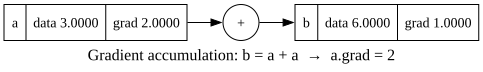

In [10]:
a = Value(3.0, label='a')
b = a + a;  b.label = 'b'
b.backward()

print(f'a.grad = {a.grad}  (expected: 2.0)')
print(f'b.grad = {b.grad}  (expected: 1.0)')

draw_dot(b, title='Gradient accumulation: b = a + a  →  a.grad = 2')

---
## 5. A Single Neuron — Full Backpropagation

A neuron computes:
$$o = \tanh\!\left(x_1 w_1 + x_2 w_2 + b\right)$$

We will:
1. Build the expression graph (forward pass)
2. Visualise the graph **before** backprop (all grads = 0)
3. Call `.backward()`
4. Visualise the graph **after** backprop (grads filled in)


### 5.1 Forward Pass

Forward pass:
  x1w1 = -6.0000
  x2w2 = 0.0000
  n    = 0.8814
  o    = tanh(n) = 0.7071


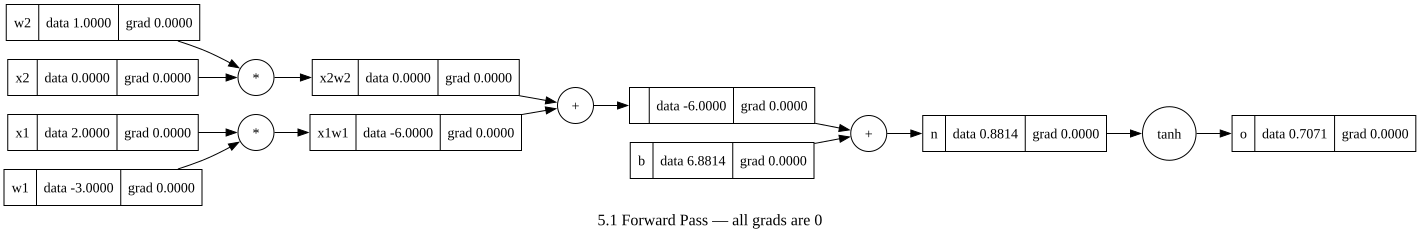

In [11]:
# Inputs
x1 = Value(2.0,  label='x1')
x2 = Value(0.0,  label='x2')
# Weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0,  label='w2')
# Bias
b  = Value(6.8813735870195432, label='b')  # chosen so tanh(n)≈0.707

# Forward
x1w1 = x1 * w1;        x1w1.label = 'x1w1'
x2w2 = x2 * w2;        x2w2.label = 'x2w2'
n    = x1w1 + x2w2 + b; n.label   = 'n'
o    = n.tanh();         o.label   = 'o'

print('Forward pass:')
print(f'  x1w1 = {x1w1.data:.4f}')
print(f'  x2w2 = {x2w2.data:.4f}')
print(f'  n    = {n.data:.4f}')
print(f'  o    = tanh(n) = {o.data:.4f}')

draw_dot(o, title='5.1 Forward Pass — all grads are 0')

### 5.2 Backward Pass

The derivative of $\tanh$ at the output gate is:
$$\frac{\partial o}{\partial n} = 1 - \tanh^2(n) = 1 - o^2$$

After that the chain rule flows through every addition and multiplication.


After backward():
  o.grad  = 1.0000   (seed = 1)
  n.grad  = 0.5000   (= 1 - tanh²(n) = 0.5000)
  x1.grad = -1.5000  (= w1 × n.grad)
  w1.grad = 1.0000   (= x1 × n.grad)
  x2.grad = 0.5000   (= w2 × n.grad)
  w2.grad = 0.0000   (= x2 × n.grad)
  b.grad  = 0.5000   (= n.grad, addition gate)


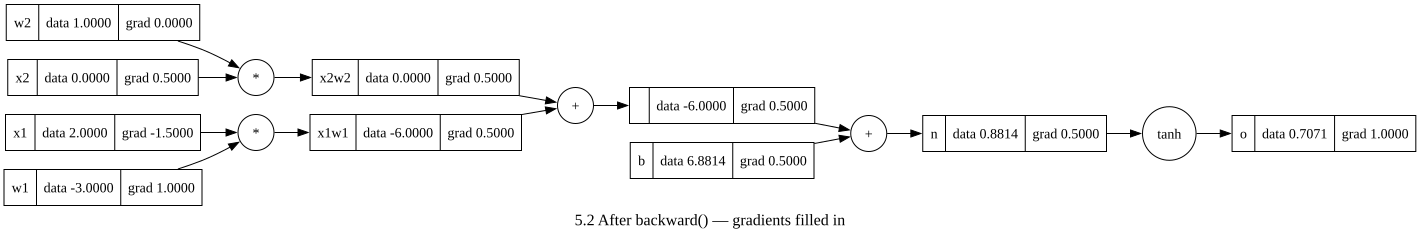

In [12]:
o.backward()

print('After backward():')
print(f'  o.grad  = {o.grad:.4f}   (seed = 1)')
print(f'  n.grad  = {n.grad:.4f}   (= 1 - tanh²(n) = {1 - o.data**2:.4f})')
print(f'  x1.grad = {x1.grad:.4f}  (= w1 × n.grad)')
print(f'  w1.grad = {w1.grad:.4f}   (= x1 × n.grad)')
print(f'  x2.grad = {x2.grad:.4f}   (= w2 × n.grad)')
print(f'  w2.grad = {w2.grad:.4f}   (= x2 × n.grad)')
print(f'  b.grad  = {b.grad:.4f}   (= n.grad, addition gate)')

draw_dot(o, title='5.2 After backward() — gradients filled in')

---
## 6. Gradient Descent — Nudging Weights to Reduce Loss

The gradient tells us **which direction increases the output**.  
To **minimise** a loss, we move in the **opposite** direction:

$$w \leftarrow w - \eta \cdot \frac{\partial L}{\partial w}$$

Below we build a tiny dataset, compute MSE loss, backprop, and update weights.


In [13]:
import random
random.seed(42)

# ── A minimal MLP for demonstration ──────────────────────────────
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1), label=f'w{i}') for i in range(nin)]
        self.b = Value(random.uniform(-1, 1), label='b')
    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        act.label = 'n'
        out = act.tanh()
        out.label = 'o'
        return out
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

# 4-example binary classification dataset
xs = [
    [2.0,  3.0, -1.0],
    [3.0, -1.0,  0.5],
    [0.5,  1.0,  1.0],
    [1.0,  1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]   # desired targets

model = MLP(3, [4, 4, 1])
print(f'Total parameters: {len(model.parameters())}')

Total parameters: 41


In [14]:
# ── Training loop ─────────────────────────────────────────────────
lr = 0.05

for step in range(25):
    # 1. Forward pass
    ypred = [model(x) for x in xs]
    loss  = sum((yp - ygt)**2 for yp, ygt in zip(ypred, ys))
    loss.label = 'loss'

    # 2. Zero gradients
    for p in model.parameters():
        p.grad = 0.0

    # 3. Backward pass
    loss.backward()

    # 4. Gradient descent update
    for p in model.parameters():
        p.data -= lr * p.grad

    if step % 5 == 0 or step == 24:
        print(f'step {step:2d}  loss = {loss.data:.6f}')

print()
print('Final predictions vs targets:')
for yp, yt in zip(ypred, ys):
    print(f'  pred: {yp.data:+.4f}   target: {yt:+.1f}')

step  0  loss = 5.230518
step  5  loss = 0.595722
step 10  loss = 0.213094
step 15  loss = 0.123364
step 20  loss = 0.084463
step 24  loss = 0.066704

Final predictions vs targets:
  pred: +0.8602   target: +1.0
  pred: -0.9187   target: -1.0
  pred: -0.8343   target: -1.0
  pred: +0.8855   target: +1.0


---
## 7. Summary — What We Learned

| Concept | Key Insight |
|---|---|
| **Forward pass** | Execute operations, build the DAG |
| **Seed gradient** | `dL/dL = 1` always |
| **Addition gate** | Distributes gradient to both inputs unchanged |
| **Multiplication gate** | Swaps the operands as local gradients |
| **tanh gate** | Local gradient = $1 - \tanh^2(x)$ |
| **Chain rule** | Multiply local gradient × upstream gradient |
| **Gradient accumulation** | Use `+=` when a node has multiple output paths |
| **Gradient descent** | Move weights in the **negative** gradient direction |

---

> **Next step**: Study how modern frameworks (PyTorch, JAX) scale this same idea
> to millions of parameters using tensor operations and GPU parallelism.
